# <span style="color:#233d4d"><b>ACTIVITY 2 </b> <i>(Logistic Regression with a Binary Outcome)</i></span>

### <span style="color:#fe7f2d">Belarmino, Llona, Ojeñar, Relayo, Sanoy, & Siao</span>

## <span style="color:#a1c181"><u>1. Importing Libraries</u></span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## <span style="color:#fcca46"><u>2. Importing Data Set</u></span>

In [2]:
data = pd.read_csv("student_pass.csv")
data

,Student,Hours_Studied,Pass
0,1,6.39,1
1,2,0.25,0
2,3,2.23,1
3,4,6.77,1
4,5,8.92,1
5,6,0.87,0
6,7,0.30,0
7,8,5.05,1
8,9,0.27,0
9,10,6.50,1


## <span style="color:#a1c181"><u>2. Visualizing Raw Data </u></span>

In [3]:
data = pd.read_csv("student_pass.csv")

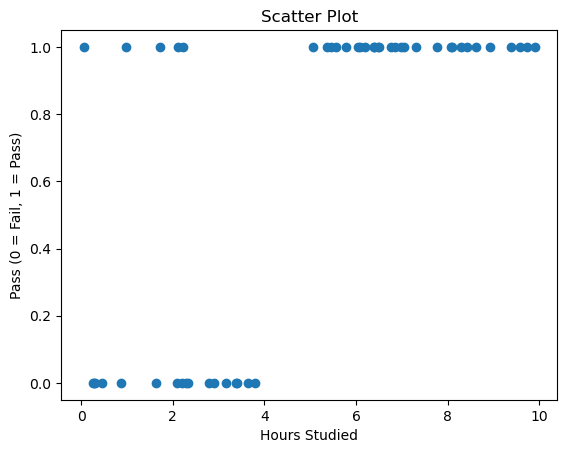

In [4]:
plt.scatter(data['Hours_Studied'], data['Pass'])
plt.xlabel('Hours Studied')
plt.ylabel('Pass (0 = Fail, 1 = Pass)')
plt.title('Scatter Plot')
plt.show()

### <span style="color:#619b8a"><u>4. Splitting Into Training and Testing Datasets</u></span>

In [5]:
X = data[['Hours_Studied']]
y = data['Pass']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## <span style="color:#233d4d"><u>5. Implementing Logistic Regression</u></span>

In [7]:
model = LogisticRegression()
model.fit (X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## <span style="color:#fe7f2d"><u>6. Predicting With Test Data</u></span>

In [8]:
predictions = model.predict(X_test)
for hours, status in zip(X_test['Hours_Studied'].values, predictions):
    status = "Pass" if status == 1 else "Fail"
    print(f"If student studied for {hours} hours, the predicted outcome is: {status}")

If student studied for 0.06 hours, the predicted outcome is: Fail
If student studied for 1.71 hours, the predicted outcome is: Fail
If student studied for 0.46 hours, the predicted outcome is: Fail
If student studied for 8.43 hours, the predicted outcome is: Pass
If student studied for 3.37 hours, the predicted outcome is: Fail
If student studied for 3.15 hours, the predicted outcome is: Fail
If student studied for 6.19 hours, the predicted outcome is: Pass
If student studied for 8.29 hours, the predicted outcome is: Pass
If student studied for 2.33 hours, the predicted outcome is: Fail
If student studied for 6.04 hours, the predicted outcome is: Pass


## <span style="color:#fcca46"><u>7. Evaluating the Model</u></span>

In [9]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 0.2
RMSE: 0.4472135954999579


## <span style="color:#a1c181"><u>8. Predicting Specific Study Hours</u></span>

In [46]:
specific_hours = pd.DataFrame({'Hours_Studied': [6.7, 9.11, 24.0, .5, 1.0, 2.0, 3.0, 4.0, 3.5, 3.2, 3.36, 3.37, 3.38, 3.39]})

predicted_status = model.predict(specific_hours)
predicted_probs = model.predict_proba(specific_hours)[:, 1]

for hr, status, prob in zip(specific_hours['Hours_Studied'], predicted_status, predicted_probs):
    result = "Pass" if status == 1 else "Fail"
    print(f"Hours Studied: {hr} -> Predicted: {result} (Probability of Passing: {prob:.4f})")

Hours Studied: 6.7 -> Predicted: Pass (Probability of Passing: 0.9574)
Hours Studied: 9.11 -> Predicted: Pass (Probability of Passing: 0.9954)
Hours Studied: 24.0 -> Predicted: Pass (Probability of Passing: 1.0000)
Hours Studied: 0.5 -> Predicted: Fail (Probability of Passing: 0.0636)
Hours Studied: 1.0 -> Predicted: Fail (Probability of Passing: 0.0978)
Hours Studied: 2.0 -> Predicted: Fail (Probability of Passing: 0.2165)
Hours Studied: 3.0 -> Predicted: Fail (Probability of Passing: 0.4134)
Hours Studied: 4.0 -> Predicted: Pass (Probability of Passing: 0.6424)
Hours Studied: 3.5 -> Predicted: Pass (Probability of Passing: 0.5294)
Hours Studied: 3.2 -> Predicted: Fail (Probability of Passing: 0.4594)
Hours Studied: 3.36 -> Predicted: Fail (Probability of Passing: 0.4967)
Hours Studied: 3.37 -> Predicted: Fail (Probability of Passing: 0.4990)
Hours Studied: 3.38 -> Predicted: Pass (Probability of Passing: 0.5014)
Hours Studied: 3.39 -> Predicted: Pass (Probability of Passing: 0.5037)


## <span style="color:#619b8a"><u>9. Plotting a Sigmoid-shaped Logistic Regression Curve</u></span>

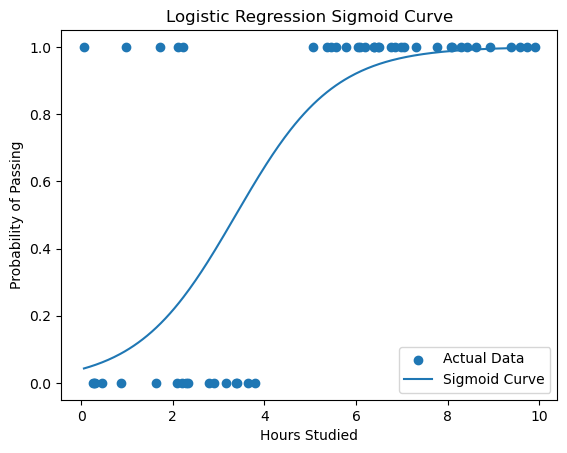

In [47]:
x_values = pd.DataFrame({
    'Hours_Studied': np.linspace(data['Hours_Studied'].min(), data['Hours_Studied'].max(), 300)
})

y_prob = model.predict_proba(x_values)[:, 1]

plt.scatter(data['Hours_Studied'], data['Pass'], label='Actual Data')
plt.plot(x_values['Hours_Studied'], y_prob, label='Sigmoid Curve')

plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing')
plt.title('Logistic Regression Sigmoid Curve')
plt.legend()
plt.show()